# MovieLens 1M Validation Experiment

In [3]:
# MovieLens 1M Validation Experiment --> Best parameters methods only!!
# BPR-MF, LightGCN, Edge SSL, SimGCL, Adaptive Noise Dense

import os
import zipfile
import random
import requests
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

overall_start = time.time()

# download MovieLens 1M

DATA_DIR = "data"
ML1M_DIR = os.path.join(DATA_DIR, "ml-1m")
ZIP_PATH = os.path.join(DATA_DIR, "ml-1m.zip")

os.makedirs(DATA_DIR, exist_ok=True)

url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"




if not os.path.exists(ML1M_DIR):
    print("Downloading MovieLens 1M...")
    r = requests.get(url)
    r.raise_for_status()

    with open(ZIP_PATH, "wb") as f:
        f.write(r.content)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

print("Dataset ready:", ML1M_DIR)






ratings_path = os.path.join(ML1M_DIR, "ratings.dat")

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    names=["user_id", "item_id", "rating", "timestamp"],
    engine="python",
    encoding="latin-1"
)

print("Raw ratings:", ratings.shape)

positive = ratings[ratings["rating"] >= 4].copy()

positive["user_id"] = positive["user_id"].astype(int) - 1
positive["item_id"] = positive["item_id"].astype(int) - 1

positive = positive.sort_values(["user_id", "timestamp"])


# train/test split: 1 positive per user


train_rows = []
test_rows = []

for user, group in positive.groupby("user_id"):
    if len(group) < 2:
        continue

    test = group.iloc[-1]
    train = group.iloc[:-1]

    test_rows.append(test)
    train_rows.append(train)

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df = pd.DataFrame(test_rows).reset_index(drop=True)

users = sorted(train_df["user_id"].unique())
items = sorted(train_df["item_id"].unique())

user_map = {u: idx for idx, u in enumerate(users)}
item_map = {i: idx for idx, i in enumerate(items)}

train_df = train_df[
    train_df["user_id"].isin(user_map) & train_df["item_id"].isin(item_map)
].copy()

test_df = test_df[
    test_df["user_id"].isin(user_map) & test_df["item_id"].isin(item_map)
].copy()

train_df["user"] = train_df["user_id"].map(user_map)
train_df["item"] = train_df["item_id"].map(item_map)

test_df["user"] = test_df["user_id"].map(user_map)
test_df["item"] = test_df["item_id"].map(item_map)

num_users = len(user_map)
num_items = len(item_map)

train_pairs = list(zip(train_df["user"].values, train_df["item"].values))
train_user_pos = train_df.groupby("user")["item"].apply(set).to_dict()
all_items = set(range(num_items))

print("Users:", num_users)
print("Items:", num_items)
print("Train pairs:", len(train_pairs))
print("Test users:", len(test_df))




# gaph helpers




def build_lightgcn_adj(num_users, num_items, interactions):
    num_nodes = num_users + num_items

    rows = []
    cols = []

    for u, i in interactions:
        item_node = num_users + i
        rows.extend([u, item_node])
        cols.extend([item_node, u])

    edge_index = torch.tensor([rows, cols], dtype=torch.long)

    deg = torch.bincount(edge_index[0], minlength=num_nodes).float()
    deg_inv_sqrt = torch.pow(deg, -0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    values = deg_inv_sqrt[edge_index[0]] * deg_inv_sqrt[edge_index[1]]

    adj = torch.sparse_coo_tensor(
        edge_index,
        values,
        size=(num_nodes, num_nodes)
    ).coalesce()

    return adj

adj = build_lightgcn_adj(num_users, num_items, train_pairs).to(device)






# models


class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, num_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def forward(self, adj):
        user_emb = self.user_embedding.weight
        item_emb = self.item_embedding.weight

        all_emb = torch.cat([user_emb, item_emb], dim=0)
        embeddings = [all_emb]

        for _ in range(self.num_layers):
            all_emb = torch.sparse.mm(adj, all_emb)
            embeddings.append(all_emb)

        final_emb = torch.mean(torch.stack(embeddings, dim=0), dim=0)

        return final_emb[:self.num_users], final_emb[self.num_users:]


class BPRMF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def forward(self):
        return self.user_embedding.weight, self.item_embedding.weight


    
    
    
    
# evaluation



    
def sample_batch(train_pairs, train_user_pos, num_items, batch_size):
    batch = random.sample(train_pairs, batch_size)

    users = []
    pos_items = []
    neg_items = []

    for u, pos in batch:
        neg = random.randint(0, num_items - 1)
        while neg in train_user_pos[u]:
            neg = random.randint(0, num_items - 1)

        users.append(u)
        pos_items.append(pos)
        neg_items.append(neg)

    return (
        torch.tensor(users, dtype=torch.long, device=device),
        torch.tensor(pos_items, dtype=torch.long, device=device),
        torch.tensor(neg_items, dtype=torch.long, device=device)
    )


def bpr_loss(user_emb, pos_emb, neg_emb):
    pos_scores = (user_emb * pos_emb).sum(dim=1)
    neg_scores = (user_emb * neg_emb).sum(dim=1)
    return -torch.mean(F.logsigmoid(pos_scores - neg_scores))


def contrastive_loss(z1, z2, temperature=0.2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)

    loss_1 = F.cross_entropy(logits, labels)
    loss_2 = F.cross_entropy(logits.T, labels)

    return (loss_1 + loss_2) / 2


def evaluate_embeddings(user_emb, item_emb, train_user_pos, test_df, num_items, k=10, num_negatives=99):
    hits = []
    recalls = []
    ndcgs = []

    users_eval = test_df["user"].values
    pos_items_eval = test_df["item"].values

    for u, true_item in zip(users_eval, pos_items_eval):
        negatives = list(all_items - train_user_pos.get(u, set()) - {true_item})

        if len(negatives) > num_negatives:
            sampled_negatives = random.sample(negatives, num_negatives)
        else:
            sampled_negatives = negatives

        candidates = sampled_negatives + [true_item]

        users_tensor = torch.tensor([u] * len(candidates), dtype=torch.long, device=device)
        items_tensor = torch.tensor(candidates, dtype=torch.long, device=device)

        with torch.no_grad():
            scores = (user_emb[users_tensor] * item_emb[items_tensor]).sum(dim=1)

        topk_indices = torch.topk(scores, min(k, len(candidates))).indices.cpu().numpy()
        topk_items = [candidates[idx] for idx in topk_indices]

        hit = int(true_item in topk_items)
        hits.append(hit)
        recalls.append(hit)

        if hit:
            rank = topk_items.index(true_item)
            ndcg = 1 / np.log2(rank + 2)
        else:
            ndcg = 0.0

        ndcgs.append(ndcg)

    return {
        f"HR@{k}": float(np.mean(hits)),
        f"Recall@{k}": float(np.mean(recalls)),
        f"NDCG@{k}": float(np.mean(ndcgs)),
    }


def evaluate_lightgcn(model, adj):
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model(adj)

    return evaluate_embeddings(
        user_emb=user_emb,
        item_emb=item_emb,
        train_user_pos=train_user_pos,
        test_df=test_df,
        num_items=num_items,
        k=10,
        num_negatives=99
    )


def evaluate_bprmf(model):
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model()

    return evaluate_embeddings(
        user_emb=user_emb,
        item_emb=item_emb,
        train_user_pos=train_user_pos,
        test_df=test_df,
        num_items=num_items,
        k=10,
        num_negatives=99
    )


    
    
    
    
# augmentations



    
def edge_dropout(train_pairs, drop_rate=0.2):
    kept_pairs = []

    for pair in train_pairs:
        if random.random() > drop_rate:
            kept_pairs.append(pair)

    if len(kept_pairs) == 0:
        kept_pairs = train_pairs

    return kept_pairs


def add_embedding_noise(embeddings, eps=0.1):
    noise = torch.rand_like(embeddings)
    noise = F.normalize(noise, dim=1)
    return embeddings + eps * torch.sign(embeddings) * noise


user_degrees = np.zeros(num_users, dtype=np.float32)
item_degrees = np.zeros(num_items, dtype=np.float32)

for u, i in train_pairs:
    user_degrees[u] += 1
    item_degrees[i] += 1

user_degrees_tensor = torch.tensor(user_degrees, dtype=torch.float32, device=device)
item_degrees_tensor = torch.tensor(item_degrees, dtype=torch.float32, device=device)


def degree_adaptive_noise(embeddings, degrees, base_eps=0.1, mode="dense"):
    degrees = degrees.float()

    min_deg = degrees.min()
    max_deg = degrees.max()

    if max_deg == min_deg:
        scale = torch.ones_like(degrees)
    else:
        norm_deg = (degrees - min_deg) / (max_deg - min_deg)

        if mode == "dense":
            scale = norm_deg
        elif mode == "sparse":
            scale = 1.0 - norm_deg
        else:
            raise ValueError("mode must be 'dense' or 'sparse'")

    scale = scale.unsqueeze(1)

    noise = torch.rand_like(embeddings)
    noise = F.normalize(noise, dim=1)

    return embeddings + base_eps * scale * torch.sign(embeddings) * noise





# training functions


def train_bprmf(model, epochs=50, batch_size=2048, lr=1e-3, reg_weight=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    for epoch in range(1, epochs + 1):
        total_loss = 0.0

        for _ in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_emb, item_emb = model()

            u_emb = user_emb[users]
            pos_emb = item_emb[pos_items]
            neg_emb = item_emb[neg_items]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            loss = loss + reg_weight * reg_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {total_loss / steps_per_epoch:.4f}")


def train_lightgcn(model, epochs=50, batch_size=2048, lr=1e-3, reg_weight=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    for epoch in range(1, epochs + 1):
        total_loss = 0.0

        for _ in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_emb, item_emb = model(adj)

            u_emb = user_emb[users]
            pos_emb = item_emb[pos_items]
            neg_emb = item_emb[neg_items]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            loss = loss + reg_weight * reg_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {total_loss / steps_per_epoch:.4f}")


def train_edge_ssl(model, epochs=50, batch_size=2048, lr=1e-3, reg_weight=1e-4, ssl_weight=0.05, drop_rate=0.2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    for epoch in range(1, epochs + 1):
        total_loss = 0.0

        pairs_view1 = edge_dropout(train_pairs, drop_rate=drop_rate)
        pairs_view2 = edge_dropout(train_pairs, drop_rate=drop_rate)

        adj_view1 = build_lightgcn_adj(num_users, num_items, pairs_view1).to(device)
        adj_view2 = build_lightgcn_adj(num_users, num_items, pairs_view2).to(device)

        for step in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_full, item_full = model(adj)

            rec_loss = bpr_loss(
                user_full[users],
                item_full[pos_items],
                item_full[neg_items]
            )

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            user_v1, item_v1 = model(adj_view1)
            user_v2, item_v2 = model(adj_view2)

            ssl_loss = (
                contrastive_loss(user_v1[users], user_v2[users], temperature=0.2)
                + contrastive_loss(item_v1[pos_items], item_v2[pos_items], temperature=0.2)
            )

            loss = rec_loss + reg_weight * reg_loss + ssl_weight * ssl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {total_loss / steps_per_epoch:.4f}")


def train_simgcl(model, epochs=50, batch_size=2048, lr=1e-3, reg_weight=1e-4, ssl_weight=0.01, noise_eps=0.05):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    for epoch in range(1, epochs + 1):
        total_loss = 0.0

        for step in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_full, item_full = model(adj)

            rec_loss = bpr_loss(
                user_full[users],
                item_full[pos_items],
                item_full[neg_items]
            )

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            user_view1 = add_embedding_noise(user_full, eps=noise_eps)
            user_view2 = add_embedding_noise(user_full, eps=noise_eps)

            item_view1 = add_embedding_noise(item_full, eps=noise_eps)
            item_view2 = add_embedding_noise(item_full, eps=noise_eps)

            ssl_loss = (
                contrastive_loss(user_view1[users], user_view2[users], temperature=0.2)
                + contrastive_loss(item_view1[pos_items], item_view2[pos_items], temperature=0.2)
            )

            loss = rec_loss + reg_weight * reg_loss + ssl_weight * ssl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {total_loss / steps_per_epoch:.4f}")


def train_adaptive_dense(model, epochs=50, batch_size=2048, lr=1e-3, reg_weight=1e-4, ssl_weight=0.01, base_eps=0.20):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    for epoch in range(1, epochs + 1):
        total_loss = 0.0

        for step in range(steps_per_epoch):
            users, pos_items, neg_items = sample_batch(
                train_pairs, train_user_pos, num_items, batch_size
            )

            user_full, item_full = model(adj)

            rec_loss = bpr_loss(
                user_full[users],
                item_full[pos_items],
                item_full[neg_items]
            )

            reg_loss = (
                model.user_embedding(users).norm(2).pow(2)
                + model.item_embedding(pos_items).norm(2).pow(2)
                + model.item_embedding(neg_items).norm(2).pow(2)
            ) / batch_size

            user_view1 = degree_adaptive_noise(
                user_full, user_degrees_tensor, base_eps=base_eps, mode="dense"
            )
            user_view2 = degree_adaptive_noise(
                user_full, user_degrees_tensor, base_eps=base_eps, mode="dense"
            )

            item_view1 = degree_adaptive_noise(
                item_full, item_degrees_tensor, base_eps=base_eps, mode="dense"
            )
            item_view2 = degree_adaptive_noise(
                item_full, item_degrees_tensor, base_eps=base_eps, mode="dense"
            )

            ssl_loss = (
                contrastive_loss(user_view1[users], user_view2[users], temperature=0.2)
                + contrastive_loss(item_view1[pos_items], item_view2[pos_items], temperature=0.2)
            )

            loss = rec_loss + reg_weight * reg_loss + ssl_weight * ssl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {total_loss / steps_per_epoch:.4f}")









# run experiments!!


ml1m_results = []

experiments = [
    ("BPR-MF", "bprmf"),
    ("LightGCN", "lightgcn"),
    ("Edge SSL", "edge_ssl"),
    ("SimGCL", "simgcl"),
    ("Adaptive Noise Dense", "adaptive_dense")
]

for name, kind in experiments:

    experiment_start = time.time()

    print("\n===================================")
    print("Running:", name)
    print("===================================")

    if kind == "bprmf":
        model = BPRMF(num_users, num_items, embedding_dim=64).to(device)
        train_bprmf(model, epochs=50, batch_size=2048)
        metrics = evaluate_bprmf(model)

    else:
        model = LightGCN(num_users, num_items, embedding_dim=64, num_layers=3).to(device)

        if kind == "lightgcn":
            train_lightgcn(model, epochs=50, batch_size=2048)
        elif kind == "edge_ssl":
            train_edge_ssl(
                model,
                epochs=50,
                batch_size=2048,
                ssl_weight=0.05,
                drop_rate=0.2
            )
        elif kind == "simgcl":
            train_simgcl(
                model,
                epochs=50,
                batch_size=2048,
                ssl_weight=0.01,
                noise_eps=0.05
            )
        elif kind == "adaptive_dense":
            train_adaptive_dense(
                model,
                epochs=50,
                batch_size=2048,
                ssl_weight=0.01,
                base_eps=0.20
            )

        metrics = evaluate_lightgcn(model, adj)

    experiment_time = time.time() - experiment_start

    row = {
        "dataset": "MovieLens 1M",
        "method": name,
        "num_train_interactions": len(train_pairs),
        "HR@10": metrics["HR@10"],
        "Recall@10": metrics["Recall@10"],
        "NDCG@10": metrics["NDCG@10"],
        "runtime_minutes": round(experiment_time / 60, 2)
    }

    ml1m_results.append(row)

    print("Result:", row)
    print(f"Finished {name} in {experiment_time / 60:.2f} minutes")

total_time = time.time() - overall_start

print("\n===================================")
print("ALL EXPERIMENTS FINISHED")
print("===================================")
print(f"Total runtime: {total_time / 60:.2f} minutes")

ml1m_results_df = pd.DataFrame(ml1m_results)

ml1m_results_df.sort_values(
    "NDCG@10",
    ascending=False
)

Device: cpu
Dataset ready: data/ml-1m
Raw ratings: (1000209, 4)
Users: 6037
Items: 3530
Train pairs: 569243
Test users: 6034


/tmp/ipykernel_16903/537093211.py:152: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  adj = torch.sparse_coo_tensor(



Running: BPR-MF
Epoch 001 | Loss: 0.6915
Epoch 010 | Loss: 0.2049
Epoch 020 | Loss: 0.1405
Epoch 030 | Loss: 0.1162
Epoch 040 | Loss: 0.1013
Epoch 050 | Loss: 0.0915
Result: {'dataset': 'MovieLens 1M', 'method': 'BPR-MF', 'num_train_interactions': 569243, 'HR@10': 0.6794829300629764, 'Recall@10': 0.6794829300629764, 'NDCG@10': 0.3951691665651431, 'runtime_minutes': 2.92}
Finished BPR-MF in 2.92 minutes

Running: LightGCN
Epoch 001 | Loss: 0.4694
Epoch 010 | Loss: 0.2560
Epoch 020 | Loss: 0.2124
Epoch 030 | Loss: 0.1888
Epoch 040 | Loss: 0.1736
Epoch 050 | Loss: 0.1639
Result: {'dataset': 'MovieLens 1M', 'method': 'LightGCN', 'num_train_interactions': 569243, 'HR@10': 0.651806430228704, 'Recall@10': 0.651806430228704, 'NDCG@10': 0.3758799971488571, 'runtime_minutes': 77.68}
Finished LightGCN in 77.68 minutes

Running: Edge SSL
Epoch 001 | Loss: 0.9881
Epoch 010 | Loss: 0.8946
Epoch 020 | Loss: 0.5671
Epoch 030 | Loss: 0.5218
Epoch 040 | Loss: 0.4982
Epoch 050 | Loss: 0.4854
Result: {'d

,dataset,method,num_train_interactions,HR@10,Recall@10,NDCG@10,runtime_minutes
4,MovieLens 1M,Adaptive Noise Dense,569243,0.696387,0.696387,0.411600,106.32
3,MovieLens 1M,SimGCL,569243,0.693570,0.693570,0.410828,109.23
2,MovieLens 1M,Edge SSL,569243,0.664402,0.664402,0.400644,230.86
0,MovieLens 1M,BPR-MF,569243,0.679483,0.679483,0.395169,2.92
1,MovieLens 1M,LightGCN,569243,0.651806,0.651806,0.375880,77.68


# MovieLens 1M - 50% Sparsity experiment

In [4]:
# MovieLens 1M - 50% Sparsity experiment

import time

def create_sparse_train_pairs(train_pairs, keep_ratio=0.5, seed=42):
    rng = np.random.default_rng(seed)
    n_keep = int(len(train_pairs) * keep_ratio)

    idx = rng.choice(
        len(train_pairs),
        size=n_keep,
        replace=False
    )

    return [train_pairs[i] for i in idx]


def build_train_user_pos_from_pairs(pairs):
    user_pos = {}

    for u, i in pairs:
        if u not in user_pos:
            user_pos[u] = set()
        user_pos[u].add(i)

    return user_pos

full_train_pairs = train_pairs
full_train_user_pos = train_user_pos
full_adj = adj
full_user_degrees_tensor = user_degrees_tensor
full_item_degrees_tensor = item_degrees_tensor



# create 50% sparse dataset
sparse50_pairs = create_sparse_train_pairs(
    full_train_pairs,
    keep_ratio=0.5,
    seed=42
)

sparse50_user_pos = build_train_user_pos_from_pairs(
    sparse50_pairs
)

sparse50_adj = build_lightgcn_adj(
    num_users,
    num_items,
    sparse50_pairs
).to(device)

train_pairs = sparse50_pairs
train_user_pos = sparse50_user_pos
adj = sparse50_adj

# recompute degrees for Adaptive Noise Dense
user_degrees = np.zeros(num_users, dtype=np.float32)
item_degrees = np.zeros(num_items, dtype=np.float32)

for u, i in train_pairs:
    user_degrees[u] += 1
    item_degrees[i] += 1

user_degrees_tensor = torch.tensor(
    user_degrees,
    dtype=torch.float32,
    device=device
)

item_degrees_tensor = torch.tensor(
    item_degrees,
    dtype=torch.float32,
    device=device
)

print("Full train interactions:", len(full_train_pairs))
print("50% sparse train interactions:", len(train_pairs))
print("Users with interactions:", len(train_user_pos))

ml1m_sparse50_results = []
overall_start = time.time()

sparse50_experiments = [
    ("LightGCN", "lightgcn"),
    ("Edge SSL", "edge_ssl"),
    ("SimGCL", "simgcl"),
    ("Adaptive Noise Dense", "adaptive_dense")
]

for name, kind in sparse50_experiments:
    experiment_start = time.time()

    print("\n===================================")
    print("Running 1M 50% sparsity:", name)
    print("===================================")

    model = LightGCN(
        num_users,
        num_items,
        embedding_dim=64,
        num_layers=3
    ).to(device)

    if kind == "lightgcn":
        train_lightgcn(
            model,
            epochs=50,
            batch_size=2048
        )

    elif kind == "edge_ssl":
        train_edge_ssl(
            model,
            epochs=50,
            batch_size=2048,
            ssl_weight=0.05,
            drop_rate=0.2
        )

    elif kind == "simgcl":
        train_simgcl(
            model,
            epochs=50,
            batch_size=2048,
            ssl_weight=0.01,
            noise_eps=0.05
        )

    elif kind == "adaptive_dense":
        train_adaptive_dense(
            model,
            epochs=50,
            batch_size=2048,
            ssl_weight=0.01,
            base_eps=0.20
        )

    metrics = evaluate_lightgcn(model, adj)

    experiment_time = time.time() - experiment_start

    row = {
        "dataset": "MovieLens 1M",
        "sparsity": "50%",
        "method": name,
        "num_train_interactions": len(train_pairs),
        "HR@10": metrics["HR@10"],
        "Recall@10": metrics["Recall@10"],
        "NDCG@10": metrics["NDCG@10"],
        "runtime_minutes": round(experiment_time / 60, 2)
    }

    ml1m_sparse50_results.append(row)

    print("Result:", row)
    print(f"Finished {name} in {experiment_time / 60:.2f} minutes")

total_time = time.time() - overall_start

print("\n===================================")
print("1M 50% SPARSITY EXPERIMENTS FINISHED")
print("===================================")
print(f"Total runtime: {total_time / 60:.2f} minutes")

ml1m_sparse50_results_df = pd.DataFrame(ml1m_sparse50_results)

display(
    ml1m_sparse50_results_df.sort_values(
        "NDCG@10",
        ascending=False
    )
)

# bring back full dataset globals after experiment
train_pairs = full_train_pairs
train_user_pos = full_train_user_pos
adj = full_adj
user_degrees_tensor = full_user_degrees_tensor
item_degrees_tensor = full_item_degrees_tensor

Full train interactions: 569243
50% sparse train interactions: 284621
Users with interactions: 6037

Running 1M 50% sparsity: LightGCN
Epoch 001 | Loss: 0.6077
Epoch 010 | Loss: 0.3132
Epoch 020 | Loss: 0.2709
Epoch 030 | Loss: 0.2465
Epoch 040 | Loss: 0.2242
Epoch 050 | Loss: 0.2106
Result: {'dataset': 'MovieLens 1M', 'sparsity': '50%', 'method': 'LightGCN', 'num_train_interactions': 284621, 'HR@10': 0.5626450116009281, 'Recall@10': 0.5626450116009281, 'NDCG@10': 0.3079871483425977, 'runtime_minutes': 20.89}
Finished LightGCN in 20.89 minutes

Running 1M 50% sparsity: Edge SSL
Epoch 001 | Loss: 0.9888
Epoch 010 | Loss: 0.9664
Epoch 020 | Loss: 0.6878
Epoch 030 | Loss: 0.5755
Epoch 040 | Loss: 0.5312
Epoch 050 | Loss: 0.5052
Result: {'dataset': 'MovieLens 1M', 'sparsity': '50%', 'method': 'Edge SSL', 'num_train_interactions': 284621, 'HR@10': 0.5865097779250912, 'Recall@10': 0.5865097779250912, 'NDCG@10': 0.32640757556110794, 'runtime_minutes': 84.29}
Finished Edge SSL in 84.29 minutes

,dataset,sparsity,method,num_train_interactions,HR@10,Recall@10,NDCG@10,runtime_minutes
2,MovieLens 1M,50%,SimGCL,284621,0.617832,0.617832,0.347075,44.86
3,MovieLens 1M,50%,Adaptive Noise Dense,284621,0.619655,0.619655,0.345224,73.15
1,MovieLens 1M,50%,Edge SSL,284621,0.586510,0.586510,0.326408,84.29
0,MovieLens 1M,50%,LightGCN,284621,0.562645,0.562645,0.307987,20.89


# Plots

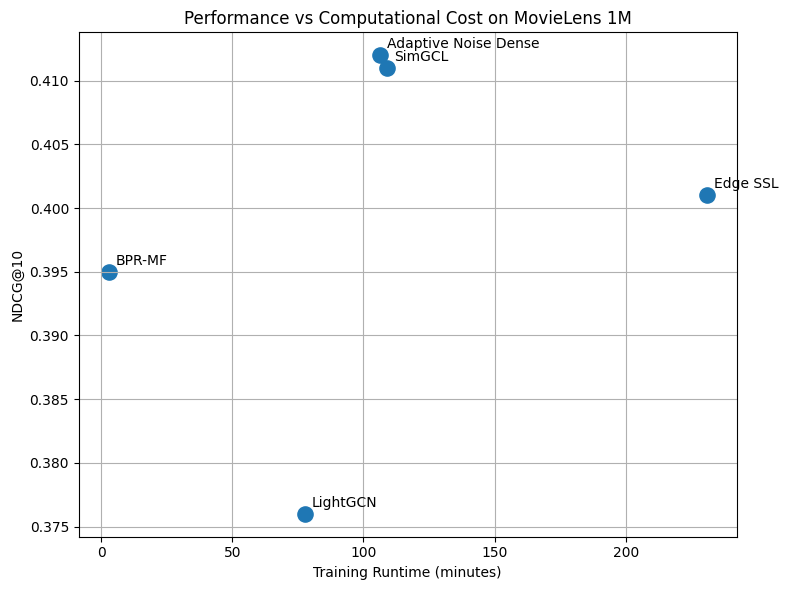

In [5]:
# extra plot for reporting

import matplotlib.pyplot as plt

methods = [
    "BPR-MF",
    "LightGCN",
    "Edge SSL",
    "SimGCL",
    "Adaptive Noise Dense"
]

runtime = [2.9, 77.7, 230.9, 109.2, 106.3]
ndcg = [0.395, 0.376, 0.401, 0.411, 0.412]

plt.figure(figsize=(8,6))

plt.scatter(runtime, ndcg, s=120)

for x, y, label in zip(runtime, ndcg, methods):
    plt.annotate(
        label,
        (x, y),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Training Runtime (minutes)")
plt.ylabel("NDCG@10")
plt.title("Performance vs Computational Cost on MovieLens 1M")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "runtime_vs_ndcg_ml1m.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# THE END!